In [1]:
import os
import random
from pathlib import Path

import ovrlpy
import pandas as pd

data_path = Path("/dh-projects/ag-ishaque/raw_data/xenium")

transcripts_path = (
    data_path
    / "Xenium_Prime_Mouse_Pup_FFPE/Xenium_Prime_Mouse_Pup_FFPE/transcripts.parquet"
)

analysis_path = Path("benchmark")
results_path = Path("results")
script_file = Path(".") / "run_ovrlpy.py"

/dh-projects/ag-ishaque/analysis/muellni/envs/ovrlpy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys

import matplotlib

sys.path.append("..")

from utils import CM, FONT, save_kwargs

matplotlib.rc("font", **FONT)

In [3]:
random.seed(42)

analysis_path.mkdir(exist_ok=True, parents=True)
results_path.mkdir(exist_ok=True, parents=True)

In [4]:
n_features = [250, 500, 1_000]  # downsampling of features
area_percentages = range(25, 100, 25)  # downsampling of tissue area [%]

# Load data

In [ ]:
coordinates = pd.read_parquet(transcripts_path)

genes = coordinates["feature_name"].unique()

is_ctrl = pd.Series(genes).str.contains("|".join(ovrlpy.io.XENIUM_CTRLS))
controls = list(genes[is_ctrl])
genes = list(genes[~is_ctrl])

n_genes = len(genes)
n_ctrls = len(controls)

print(f"Genes: {n_genes}")
print(f"Controls: {n_ctrls}")

# Generate datasets 

## Downsample #features

To make the benchmark realistic and avoid sampling effects of genes vs controls we are going to downsample both separately but at the same ratio.

In [ ]:
# downsample genes
for n in n_features:
    fraction = n / n_genes
    keep_genes = random.sample(genes, n)
    keep_ctrls = random.sample(controls, round(n_ctrls * fraction))

    coordinates.loc[
        lambda df: df["feature_name"].isin(keep_genes + keep_ctrls)
    ].to_parquet(analysis_path / f"{n}_genes.parquet", index=False)

## Downsample area

To downsample by area we are going to crop x% of the area centered on the middle of the sample and along both axis.

This will have some non-linear effects due to the tissue not covering the whole area though.

We will use the downsampled 1k panel for benchmarking the area

In [ ]:
area_default = analysis_path / "1000_genes.parquet"

In [ ]:
coordinates = pd.read_parquet(area_default)

In [ ]:
x_min, y_min = coordinates[["x_location", "y_location"]].min()
x_max, y_max = coordinates[["x_location", "y_location"]].max()

x_range = x_max - x_min
y_range = y_max - y_min

center_x = x_range / 2 + x_min
center_y = y_range / 2 + y_min

In [ ]:
from math import sqrt

for area in area_percentages:
    size_factor = sqrt(area / 100)
    x_range_downsampled = x_range * size_factor / 2
    x_ = center_x - x_range_downsampled
    _x = center_x + x_range_downsampled

    y_range_downsampled = y_range * size_factor / 2
    y_ = center_y - y_range_downsampled
    _y = center_y + y_range_downsampled

    coordinates.loc[
        lambda df: (df["x_location"] > x_)
        & (df["x_location"] < _x)
        & (df["y_location"] > y_)
        & (df["y_location"] < _y)
    ].to_parquet(analysis_path / f"{area}%_area.parquet", index=False)

In [ ]:
del coordinates

## Stats

In [26]:
transcripts = ovrlpy.io.read_Xenium(analysis_path / "1000_genes.parquet")

xmin, ymin = transcripts["x", "y"].min().row(0)
xmax, ymax = transcripts["x", "y"].max().row(0)

area = (xmax - xmin) * (ymax - ymin)

print(f"# transcripts: {len(transcripts):,}")
print(f"area {area / 10**6:.1f} mm²")

del transcripts

# transcripts: 125,756,304
area 272.6 mm²


# Benchmark

In [ ]:
memory = 64  # in GB
time = 12  # in h
default_threads = 8

# ensure submitting to nodes with same hardware
partition = "-p compute-96cpu-700GB-RAM"

# run exclusively on single node
nodes = "-N 1 --exclusive"

In [ ]:
# as the dataset we are going to use the downsampled 1k panel
dataset = analysis_path / "1000_genes.parquet"

In [ ]:
# command for activating conda environment
conda_env = "ovrlpy"
conda_path = "~/miniconda3/bin/activate"

conda_cmd = f"source {conda_path} {conda_env}"

In [ ]:
def get_id_dataframe(jobs: dict, key="job"):
    return (
        pd.DataFrame(jobs)
        .assign(jobid=lambda df: df[key].str.extract(r"(\d+)$").astype(int))
        .drop(columns=[key])
        .set_index("jobid")
    )

## Scalability with #threads

In [ ]:
job_ids = []

for n_threads in [1, 2, 4, 8, 16]:
    log = analysis_path / f"Threads-{n_threads}.txt"
    cmd = f"{script_file.resolve()} {dataset} --n_threads {n_threads} "

    id_string = os.popen(
        f"sbatch -J ovrlpy --mem={memory}G -c {n_threads} -n 1 "
        f"-o {log} "
        f"--time={time}:00:00 "
        f"{partition} {nodes} "
        f'--wrap="{conda_cmd} && {cmd}" '
    ).read()
    id_string = id_string.strip()

    job_ids.append({"threads": n_threads, "job": id_string})

job_ids_threads = get_id_dataframe(job_ids)
job_ids_threads.to_csv(results_path / "jobs_threads.tsv", sep="\t")

## Scalability with #features

In [ ]:
job_ids = []

for n in n_features + [None]:
    input_path = transcripts_path if n is None else analysis_path / f"{n}_genes.parquet"

    log = analysis_path / f"Genes-{n}.txt"
    cmd = f"{script_file.resolve()} {input_path} --n_threads {default_threads} "

    id_string = os.popen(
        f"sbatch -J ovrlpy --mem={memory}G -c {default_threads} -n 1 "
        f"-o {log} "
        f"--time={time}:00:00 "
        f"{partition} {nodes} "
        f'--wrap="{conda_cmd} && {cmd}" '
    ).read()
    id_string = id_string.strip()

    job_ids.append({"features": n if n is not None else 5_010, "job": id_string})

job_ids_features = get_id_dataframe(job_ids)
job_ids_features.to_csv(results_path / "jobs_features.tsv", sep="\t")

## Scalability with area

In [ ]:
job_ids = []

for area in list(area_percentages) + [None]:
    input_path = dataset if area is None else analysis_path / f"{area}%_area.parquet"

    log = analysis_path / f"Area-{area}.txt"
    cmd = f"{script_file.resolve()} {input_path} --n_threads {default_threads} "

    id_string = os.popen(
        f"sbatch -J ovrlpy --mem={memory}G -c {default_threads} -n 1 "
        f"-o {log} "
        f"--time={time}:00:00 "
        f"{partition} {nodes} "
        f'--wrap="{conda_cmd} && {cmd}" '
    ).read()
    id_string = id_string.strip()

    job_ids.append({"area": area if area is not None else 100, "job": id_string})

job_ids_area = get_id_dataframe(job_ids)
job_ids_area.to_csv(results_path / "jobs_area.tsv", sep="\t")

# Results

In [5]:
import os
import re
from datetime import timedelta
from io import StringIO

import pandas as pd


def parse_sacct_time(time_str):
    pattern = r"(?:(?P<day>\d+)-)?(?:(?P<hour>\d{1,2}):)?(?P<min>\d{2}):(?P<sec>\d{2})(?:.(?P<usec>\d+))?"
    match = re.match(pattern, time_str)

    if not match:
        raise ValueError("Invalid SLURM time format")

    days = int(match.group("day")) if match.group("day") else 0
    hours = int(match.group("hour")) if match.group("hour") else 0
    minutes = int(match.group("min"))
    seconds = int(match.group("sec"))
    microseconds = int(match.group("usec")) if match.group("usec") else 0

    time = timedelta(
        days=days,
        hours=hours,
        minutes=minutes,
        seconds=seconds,
        microseconds=microseconds,
    )

    return time.total_seconds()


def get_runtime_stats(job_ids: pd.DataFrame):
    job_stats = os.popen(
        (
            "sacct "
            f"-j {','.join(job_ids.index.astype(str))} "
            "--format='JobID,Jobname%50,TotalCPU,ElapsedRaw,MaxRSS,State' "
            "-P --delimiter=$'\t' "
            "--units=M "
        )
    ).read()

    job_stats = pd.read_table(StringIO(job_stats))

    cpu_stats = (
        job_stats.loc[
            lambda df: ~df["JobID"].str.contains(".", regex=False),
            ["JobID", "JobName", "TotalCPU", "ElapsedRaw", "State"],
        ]
        .assign(
            JobID=lambda df: df["JobID"].astype(int),
            TotalCPU=lambda df: df["TotalCPU"].map(parse_sacct_time),
        )
        .set_index("JobID")
        .rename(columns={"TotalCPU": "CPU time [s]", "ElapsedRaw": "wall time [s]"})
    )

    memory_stats = (
        job_stats.loc[
            lambda df: df["JobID"].str.contains(".batch", regex=False),
            ["JobID", "MaxRSS"],
        ]
        .assign(
            JobID=lambda df: df["JobID"].str.extract(r"(\d+)").astype(int),
            MaxRSS=lambda df: df["MaxRSS"].str.extract(r"([\d\\.]+)").astype(float),
        )
        .set_index("JobID")
        .rename(columns={"MaxRSS": "max memory [MB]"})
    )

    return (
        cpu_stats.join(memory_stats)
        .join(job_ids, how="inner")
        .drop(columns=["JobName"])
    )

In [6]:
job_ids_threads = pd.read_table(results_path / "jobs_threads.tsv", index_col="jobid")
job_ids_features = pd.read_table(results_path / "jobs_features.tsv", index_col="jobid")
job_ids_area = pd.read_table(results_path / "jobs_area.tsv", index_col="jobid")

In [7]:
stats_threads = get_runtime_stats(job_ids_threads)
stats_features = get_runtime_stats(job_ids_features)
stats_area = get_runtime_stats(job_ids_area)

In [8]:
stats_area = stats_area.rename(columns={"area": "area [%]"})

In [10]:
stats_threads[["CPU time [s]", "wall time [s]", "max memory [MB]", "threads"]].to_csv(
    results_path / "performance_threads.tsv", sep="\t", index=False
)

stats_features[["CPU time [s]", "wall time [s]", "max memory [MB]", "features"]].to_csv(
    results_path / "performance_features.tsv", sep="\t", index=False
)

stats_area[["CPU time [s]", "wall time [s]", "max memory [MB]", "area [%]"]].to_csv(
    results_path / "performance_area.tsv", sep="\t", index=False
)

In [11]:
def transform_units(df):
    return df.assign(
        **{
            "time [h]": lambda df: df["wall time [s]"] / 3_600,
            "max memory [GB]": lambda df: df["max memory [MB]"] / 1_000,
        }
    )

In [12]:
stats_threads = transform_units(stats_threads)
stats_features = transform_units(stats_features)
stats_area = transform_units(stats_area)

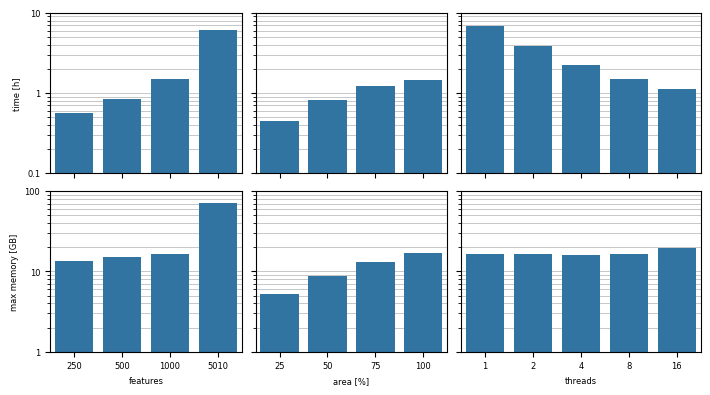

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(
    2, 3, figsize=(18 * CM, 10 * CM), sharex="col", sharey="row", width_ratios=[4, 4, 5]
)


sns.barplot(stats_features, x="features", y="time [h]", ax=axs[0, 0])
sns.barplot(stats_features, x="features", y="max memory [GB]", ax=axs[1, 0])
sns.barplot(stats_area, x="area [%]", y="time [h]", ax=axs[0, 1])
sns.barplot(stats_area, x="area [%]", y="max memory [GB]", ax=axs[1, 1])
sns.barplot(stats_threads, x="threads", y="time [h]", ax=axs[0, 2])
sns.barplot(stats_threads, x="threads", y="max memory [GB]", ax=axs[1, 2])

axs[0, 0].set(yscale="log", ylim=(0.1, 10))
axs[0, 0].set_yticks([0.1, 1, 10], [0.1, 1, 10])

axs[1, 0].set(yscale="log", ylim=(1, 100))
axs[1, 0].set_yticks([1, 10, 100], [1, 10, 100])
axs[1, 0].yaxis.set_minor_formatter(plt.NullFormatter())

for ax in axs.ravel():
    ax.grid(which="both", axis="y", linestyle="-", linewidth=0.5)
    ax.set_axisbelow(True)

fig.tight_layout()

fig.savefig("benchmark.png", **save_kwargs)
fig.savefig("benchmark.svg", **save_kwargs)